In [1]:
import pandas as pd

In [2]:
import kagglehub


path = kagglehub.dataset_download("shrutimechlearn/churn-modelling")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'churn-modelling' dataset.
Path to dataset files: /kaggle/input/churn-modelling


In [3]:
import os

# Join the folder path with the specific file name
file_path = os.path.join(path, 'Churn_Modelling.csv')

# Now read the file using that full address
df = pd.read_csv(file_path)

In [4]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [5]:
# We drop the 3 irrelevant columns AND the target column from X
X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)   #axis=1 is for , the model to look at coluns nd axis=0 for rows
y = df['Exited']

In [22]:
#One-hot encoding

X = pd.get_dummies(X, drop_first=True)


We apply get_dummies to X to turn Geography and Gender into numbers

By setting drop_first=True, we kick out that first redundant column.

0 means the category we dropped (e.g., Female).

1 means the category we kept (e.g., Male).

It makes the dataset leaner and prevents the math from "tripping" over itself. 🏃‍♂️

In [7]:
import tensorflow as tf
#giant toolbox that contains everything needed for artificial intelligence.

from tensorflow.keras.models import Sequential
#Sequential as an empty "stack" or a "container." It allows us to add layers one by one, in order, from the input to the output.

from tensorflow.keras.layers import Dense
#In a Dense layer, every neuron is connected to every neuron in the previous layer. These connections are where the model stores what it "learns."

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Scaling the numbers (The AI likes small, similar ranges)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [14]:
# Initialize the container
ann = Sequential()

In [15]:
# Layer 1: 10 neurons
ann.add(Dense(units=10, activation='relu'))
ann.add(Dense(units=15, activation='relu'))
ann.add(Dense(units=19, activation='relu'))
ann.add(Dense(units=24, activation='relu'))
ann.add(Dense(units=28, activation='relu'))

# ann: the container for your whole neural network.

# .add(): action of physically attaching a new layer to the stack.

# Dense: tells the computer that this layer is "fully connected." In a dense layer, every single neuron in the new layer is connected to every single neuron in the previous layer.

# units=...: This defines the number of neurons 🧠 (processing nodes) in that specific layer. For example, units=19 means that specific "floor" of your building has 19 workers (neurons) collaborating to find patterns in the data.

#WHY ReLu?
# If the input is negative, ReLU turns it into 0. If the input is positive, it stays exactly as it is.
# helps the network learn complex, non-linear patterns.

In [16]:
ann.add(Dense(units=1, activation='sigmoid'))

#sigmoid squashes the result into a probability between 0 and 1.
#we used unit=1 cuz we want only 1 output from the model to give.

In [17]:
# Compiling the ANN
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])


# ann.compile: configuring the learning process before it starts.

#Optimizer: The "driver" that adjusts the weights of the neurons to reduce errors. Adam is a very popular choice. 🏎️

#For binary (Yes/No) tasks, we use binary_crossentropy. 📏

#Metrics: What we want to track to see how well it's doing, like accuracy. ✅


In [18]:
# Training the ANN on the Training set
history = ann.fit(X_train, y_train, batch_size = 32, epochs = 100, validation_data=(X_test, y_test))

#ann.fit:the actual "studying" phase. The model looks at the features (X_train) and the answers (y_train) to find patterns.

#batch_size = 32: Instead of looking at 10,000 rows all at once, the model looks at 32 rows, updates its "brain," and moves to the next 32. It’s like reading a book in small paragraphs rather than the whole page at once. 📖

#history: We save the training progress in this variable so we can use it to draw graphs later.

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7891 - loss: 0.5288 - val_accuracy: 0.7975 - val_loss: 0.4363
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8122 - loss: 0.4337 - val_accuracy: 0.8370 - val_loss: 0.4137
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8235 - loss: 0.4027 - val_accuracy: 0.8470 - val_loss: 0.3892
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8327 - loss: 0.3928 - val_accuracy: 0.8475 - val_loss: 0.3734
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8419 - loss: 0.3739 - val_accuracy: 0.8575 - val_loss: 0.3614
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8517 - loss: 0.3631 - val_accuracy: 0.8580 - val_loss: 0.3551
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8530 - loss: 0.3510 - val_accuracy: 0.8570 - val_loss: 0.3597
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8573 - loss: 0.3452 - val_accu

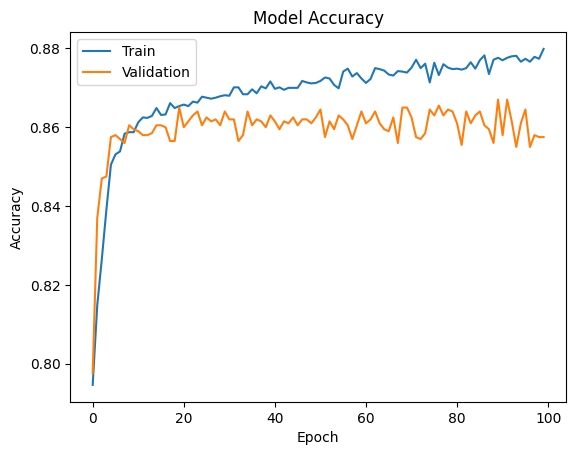

In [21]:
import matplotlib.pyplot as plt

# Plotting Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()